In [3]:
import cv2
import json
import numpy as np


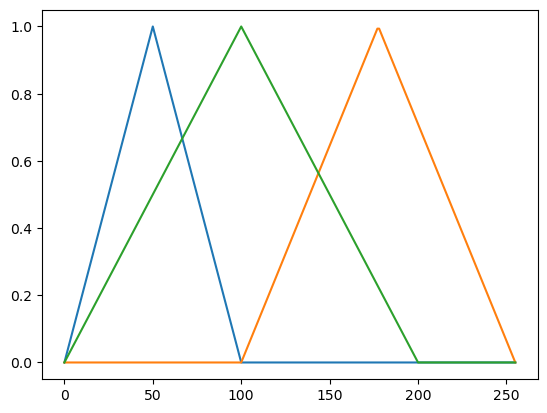

In [5]:
from fuzzylogic.classes import Domain
from fuzzylogic.functions import triangular

rojo = Domain("Rojo",0,255)
azul = Domain("Azul",0,255)
verde = Domain("Verde",0,255)

rojo.triangular = triangular(0,100)
verde.triangular = triangular(100,255)
azul.triangular = triangular(0,200)

rojo.triangular.plot()
verde.triangular.plot()
azul.triangular.plot()

In [8]:

# Función para procesar la imagen y detectar un rango de colores
def detectar_color(imagen, rango_color):
    """Busca obstáculos verificando que los colores en la imagen no están en un rango
    conocido que corresponde al paisaje.
    Para la búsqueda se utilizaron paisajes con brillo, con atardeceres, normales.
    Se buscó el histograma de colores de cada uno y se comparó.

    Args:
        imagen (cv2.Image): Imagen que se desea analizar
        rango_color (): Rango de colores correspondiente a los obstáculos

    Returns:
        resultado: Retorna la imagen del color
    """
    hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)
    
    # Definir un rango de colores en formato HSV
    rango_bajo = np.array(rango_color[0])
    rango_alto = np.array(rango_color[1])
    mascara = cv2.inRange(hsv, rango_bajo, rango_alto)

    # Aplicar la máscara a la imagen original
    resultado = cv2.bitwise_and(imagen, imagen, mask=mascara)

    return resultado

if __name__ == "__main__":
    # Capturar imagen de la cámara (reemplazar con tu propia lógica para obtener imágenes)
    image_path = json.load(open("config.json"))["img_path"] + "barco.jpg"
    imagen_camara = cv2.imread(image_path)
    scale_percent = 40 # percent of original size
    width = int(imagen_camara.shape[1] * scale_percent / 100)
    height = int(imagen_camara.shape[0] * scale_percent / 100)
    dim = (width, height)
    imagen_camara = cv2.resize(imagen_camara,dim,interpolation = cv2.INTER_AREA)
    # Definir el rango de color (ajustar según el objeto que estás buscando)
    rango_color = [[0, 100, 0], [100, 255, 200]]  # Rango bajo, Rango alto
    
    hsv = cv2.cvtColor(imagen_camara, cv2.COLOR_BGR2HSV)
    
    # Definir un rango de colores en formato HSV
    rango_bajo = np.array(rango_color[0])
    rango_alto = np.array(rango_color[1])
    
    mascara = cv2.inRange(hsv, rango_bajo, rango_alto)
    
    resultado = cv2.bitwise_and(imagen_camara, imagen_camara, mask=mascara)
    
    # Horizontally concatenate the 2 images
    img3 = cv2.hconcat([imagen_camara,resultado])
    
    cv2.imshow('Imagen hsv', img3)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

In [26]:

# Cantidad de pixeles
mascara = np.any(resultado != [0,0,0], axis=-1)
pixeles = resultado[mascara]
cantidad = mascara.sum()
len(np.unique(pixeles,axis=-1))

# Reglas
## Si hay pocos colores distintos
## Si hay muchos pixeles de color anormal

4673